In [2]:
from riskmodels import RiskModelsClient
import os
os.getenv("RISKMODELS_API_KEY")
client = RiskModelsClient.from_env()
from Data import get_data, get_tickers, get_price_data, add_sector_subsector
import os
os.environ['GRPC_VERBOSITY'] = 'NONE'
os.environ['GLOG_minloglevel'] = '3'
import logging, warnings
logging.getLogger('hmmlearn').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=Warning, module='riskmodels')

Supabase credentials not wired (need SUPABASE_URL + SUPABASE_SERVICE_ROLE_KEY, or the NEXT_PUBLIC_* equivalents). Supabase-backed SDK methods (get_ticker_metadata, peer_group_from_supabase) will raise ValueError at call time, and FundData enrichment will silently skip the Supabase round-trip. Set the env vars to silence this warning.


In [3]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'JPM',
           'V', 'JNJ', 'WMT', 'PG', 'XOM', 'HD', 'BAC', 'KO', 'DIS', 'CSCO',
           'PFE', 'INTC']

In [4]:
df = get_data(tickers=tickers, client=client, method=1, resample_window='W')
g = (df.dropna(subset=['sector','subsector'])
       .groupby(['sector','subsector'])['ticker'].nunique()
       .sort_values(ascending=False))
print(g)
print("usable groups (>=2 tickers):", int((g >= 2).sum()))
print("tickers in a usable group:", int(g[g >= 2].sum()))

/Users/aman/Desktop/Conrad/v2.0/v2.6/Data.py:78: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench',
/Users/aman/miniconda3/envs/ml_course/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/aman/miniconda3/envs/ml_course/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new r

sector   subsector
FFX_XLF  FFX_4810     2
FFX_XLK  FFX_SMH      2
FFX_XLV  FFX_2320     2
FFX_XLY  FFX_XRT      2
FFX_XLC  FFX_FDN      1
         FFX_GGME     1
FFX_XLE  FFX_XES      1
FFX_XLF  FFX_IYG      1
FFX_XLK  FFX_IDGT     1
         FFX_IGV      1
         FFX_RSPT     1
FFX_XLP  FFX_IYK      1
         FFX_PBJ      1
         FFX_XRT      1
FFX_XLY  FFX_CARZ     1
Name: ticker, dtype: int64
usable groups (>=2 tickers): 4
tickers in a usable group: 8


In [5]:
g = (df.dropna(subset=['sector','subsector'])
       .groupby(['sector','subsector'])['ticker']
       .apply(lambda s: sorted(s.unique())))

usable = g[g.apply(len) >= 2]

print("usable groups (>=2 tickers):", len(usable))
for (sec, sub), names in usable.items():
    print(f"  {sec} / {sub}: {names}")

used_tickers = sorted({t for names in usable for t in names})
print("\ntickers actually used:", used_tickers)
print("count:", len(used_tickers))

usable groups (>=2 tickers): 4
  FFX_XLF / FFX_4810: ['BAC', 'JPM']
  FFX_XLK / FFX_SMH: ['INTC', 'NVDA']
  FFX_XLV / FFX_2320: ['JNJ', 'PFE']
  FFX_XLY / FFX_XRT: ['AMZN', 'HD']

tickers actually used: ['AMZN', 'BAC', 'HD', 'INTC', 'JNJ', 'JPM', 'NVDA', 'PFE']
count: 8


In [ ]:
from backtest_global import  backtest_global
from forward_beta import get_market_cap
df = get_market_cap(client, df, df['ticker'].unique())
bt = backtest_global(df, method=1, resample_window='W', book='mvo')


  2013-01-13  [1/708]  port=-2.61% spy=+0.48% | held=7/8 | TOTAL port=-2.6% spy=+0.5%
  2013-07-07  [26/708]  port=+1.91% spy=+1.62% | held=6/8 | TOTAL port=+12.7% spy=+12.5%
  2013-12-29  [51/708]  port=+0.23% spy=+1.26% | held=8/8 | TOTAL port=+33.6% spy=+28.1%
  2014-06-22  [76/708]  port=-1.60% spy=+1.42% | held=7/8 | TOTAL port=+40.9% spy=+37.8%
  2014-12-14  [101/708]  port=-4.52% spy=-3.42% | held=5/8 | TOTAL port=+46.4% spy=+42.0%
  2015-06-07  [126/708]  port=+0.14% spy=-0.65% | held=8/8 | TOTAL port=+78.9% spy=+49.7%
  2015-11-29  [151/708]  port=+0.57% spy=+0.12% | held=7/8 | TOTAL port=+149.9% spy=+51.1%
  2016-05-22  [176/708]  port=+4.18% spy=+0.36% | held=5/8 | TOTAL port=+194.9% spy=+49.8%
  2016-11-13  [201/708]  port=+17.23% spy=+3.77% | held=7/8 | TOTAL port=+344.1% spy=+59.4%
  2017-05-07  [226/708]  port=+0.14% spy=+0.68% | held=7/8 | TOTAL port=+437.1% spy=+78.4%
  2017-10-29  [251/708]  port=+5.62% spy=+0.23% | held=8/8 | TOTAL port=+726.8% spy=+93.6%
  2018-04-2

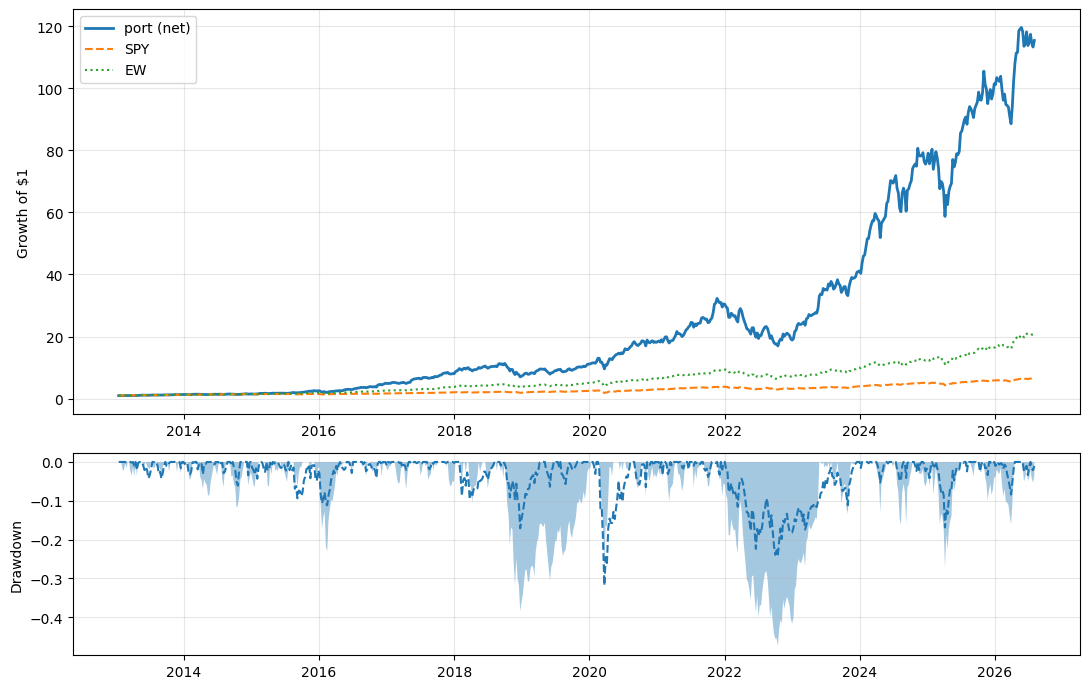

In [ ]:
import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), height_ratios=[2, 1])
a1.plot(bt['date'], bt['port_growth_net'], label='port (net)', lw=2)
a1.plot(bt['date'], bt['spy_growth'], '--', label='SPY')
a1.plot(bt['date'], bt['ew_growth'], ':', label='EW')
a1.set_ylabel('Growth of $1'); a1.legend(); a1.grid(alpha=.3)
dd = lambda g: g / g.cummax() - 1
a2.fill_between(bt['date'], dd(bt['port_growth_net']), 0, alpha=.4)
a2.plot(bt['date'], dd(bt['spy_growth']), '--'); a2.set_ylabel('Drawdown'); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()